# Vehicle Valuation Platform — V1 Modeling

## 1. Load Frozen V1 Data

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn import datasets
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor


X_train = pd.read_parquet("../data/V1_processed/X_train.parquet")
X_val   = pd.read_parquet("../data/V1_processed/X_val.parquet")
X_test  = pd.read_parquet("../data/V1_processed/X_test.parquet")

y_train = pd.read_parquet("../data/V1_processed/y_train.parquet")["price"]
y_val   = pd.read_parquet("../data/V1_processed/y_val.parquet")["price"]
y_test  = pd.read_parquet("../data/V1_processed/y_test.parquet")["price"]

In [3]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2130184, 21) (2130184,)
(266269, 21) (266269,)
(266276, 21) (266276,)


## 2. Define V1 Operating Scope

In [4]:
y_train.value_counts(
    bins=[0, 1_000, 50_000, 100_000, 150_000, 200_000, 250_000, float("inf")],
    sort=False
)


(-0.001, 1000.0]             57
(1000.0, 50000.0]       1902659
(50000.0, 100000.0]      214865
(100000.0, 150000.0]       8668
(150000.0, 200000.0]       2206
(200000.0, 250000.0]        855
(250000.0, inf]             874
Name: count, dtype: int64

In [5]:
upper_mask = y_train.between(200_000, 250_000)

X_train.loc[upper_mask, "model_name"].value_counts().head(20)

model_name
R8                104
AMG GT             67
S-Class            53
911                49
Taycan             46
488                45
G-Class            44
DB11               38
Portofino          30
F12 Berlinetta     30
458 Italia         27
Huracan            24
GT                 23
Dawn               21
GTC4Lusso T        21
600LT              20
Urus               16
Continental GT     15
720S               13
GTC4Lusso          12
Name: count, dtype: int64

In [6]:
y_val.value_counts(
    bins=[0, 1_000, 50_000, 100_000, 150_000, 200_000, 250_000, float("inf")],
    sort=False
)

(-0.001, 1000.0]             4
(1000.0, 50000.0]       237629
(50000.0, 100000.0]      27050
(100000.0, 150000.0]      1107
(150000.0, 200000.0]       291
(200000.0, 250000.0]       104
(250000.0, inf]             84
Name: count, dtype: int64

In [7]:
val_upper_mask = y_val.between(200_000, 250_000)

X_val.loc[val_upper_mask, "model_name"].value_counts().head(20)

model_name
R8                   13
AMG GT                9
DB11                  6
488                   6
911                   6
Wraith                6
G-Class               5
GT                    4
Panamera E-Hybrid     4
Portofino             4
Taycan                3
S-Class               3
Urus                  3
458 Italia            3
F12 Berlinetta        2
Huracan               2
675LT                 2
GTC4Lusso             2
600LT                 2
Dawn                  1
Name: count, dtype: int64

### Apply V1 Price Range

In [3]:
Lower_price = 1000
Upper_price = 200000

train_mask=y_train.between(Lower_price, Upper_price)
val_mask =y_val.between(Lower_price, Upper_price)

X_train_V1 = X_train.loc[train_mask].copy()
y_train_V1 = y_train.loc[train_mask].copy()

X_val_v1 = X_val.loc[val_mask].copy()
y_val_v1 = y_val.loc[val_mask].copy()

In [4]:
X_val_v1

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,salvage,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported
511069,Apollo,V6,Not Reported,Gasoline,Not Reported,375.0,True,Ford,23.0,F-150,...,Not Reported,Unknown,Lariat SuperCrew 4WD,4WD,2020,0,0,False,False,False
171176,Tyler,V6,False,Gasoline,False,268.0,False,Lexus,43864.0,ES 350,...,False,A,350 FWD,FWD,2018,0,0,False,False,True
1773867,Salt Lake City,I4,Not Reported,Gasoline,Not Reported,170.0,True,Nissan,0.0,Rogue,...,Not Reported,CVT,SV AWD,AWD,2020,0,0,False,False,False
1682907,Forest Lake,V6,False,Gasoline,True,283.0,False,Dodge,89243.0,Journey,...,False,A,R/T AWD,AWD,2014,0,0,False,False,True
647827,Cockeysville,V6,Not Reported,Gasoline,Not Reported,285.0,True,Jeep,1.0,Gladiator,...,Not Reported,A,Rubicon Crew Cab 4WD,4WD,2020,0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495748,Shorewood,I4,False,Gasoline,False,178.0,False,Ford,70761.0,Transit Connect,...,False,A,Cargo XLT LWB FWD with Rear Cargo Doors,FWD,2016,0,0,False,False,True
183464,Lodi,I4,False,Gasoline,True,170.0,False,Volkswagen,29216.0,Golf Alltrack,...,False,A,SE 4Motion AWD,AWD,2017,0,0,False,False,True
1152766,Omaha,I4,False,Gasoline,False,185.0,False,Kia,33996.0,Sorento,...,False,A,LX FWD,FWD,2017,0,0,False,False,True
1181365,Daytona Beach,I4,False,Gasoline,False,180.0,False,Buick,14768.0,Verano,...,False,A,Convenience FWD,FWD,2016,0,0,False,False,True


In [6]:
import sys

sys.path.insert(0, str(Path.cwd().parent))

In [10]:
from src.predict import predict_price

sample_vehicle = X_val_v1.iloc[200000].to_dict()

predicted_price = predict_price(sample_vehicle)
actual_price = float(y_val_v1.iloc[200000])

print(f"Predicted price: ${predicted_price:,.2f}")
print(f"Actual price:    ${actual_price:,.2f}")

Predicted price: $18,635.33
Actual price:    $18,092.00


In [9]:
y_train_V1.min()

np.float64(1000.0)

In [10]:
y_train_V1.max()

np.float64(200000.0)

In [11]:
X_train_V1.isna().sum().sort_values(ascending=False)

city                        0
engine_type                 0
frame_damaged               0
fuel_type                   0
has_accidents               0
horsepower                  0
is_new                      0
make_name                   0
mileage                     0
model_name                  0
owner_count                 0
salvage                     0
transmission                0
trim_name                   0
wheel_system                0
year                        0
mileage_missing             0
horsepower_missing          0
new_mileage_conflict        0
used_owner_count_missing    0
Condition_reported          0
dtype: int64

In [12]:
X_train_V1.shape

(2128455, 21)

In [13]:
y_train_V1.shape

(2128455,)

## 3. Preprocessing

In [14]:
categorical_cols = ['city', 'make_name', 'model_name','trim_name','engine_type','frame_damaged','fuel_type','has_accidents','salvage','transmission','wheel_system'] 

categoric_transformer= ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_cols)


numerical_cols = ['horsepower', 'mileage', 'owner_count', 'year']
numeric_transformer = ('num', StandardScaler(), numerical_cols)



boolean_cols =['is_new',
 'mileage_missing',
 'horsepower_missing',
 'Condition_reported',
 'new_mileage_conflict',
 'used_owner_count_missing'] 
boolean_transformer = ("bool", "passthrough", boolean_cols)

preprocessor = ColumnTransformer(
    transformers=[
        numeric_transformer,
        categoric_transformer,
        boolean_transformer
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train_V1)
X_val_processed = preprocessor.transform(X_val_v1)


## 4. Baseline — Linear Regression

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train_V1)

train_pred = lr_model.predict(X_train_processed)
val_pred = lr_model.predict(X_val_processed)

mae = mean_absolute_error(y_val_v1, val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_V1, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val_v1, val_pred))
r2 = r2_score(y_val_v1, val_pred)

print("MAE:", mae)
print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("R²:", r2)

MAE: 2957.738962769356
Train RMSE: 4573.83612584616
Validation RMSE: 4671.17227524493
R²: 0.9294197115541609


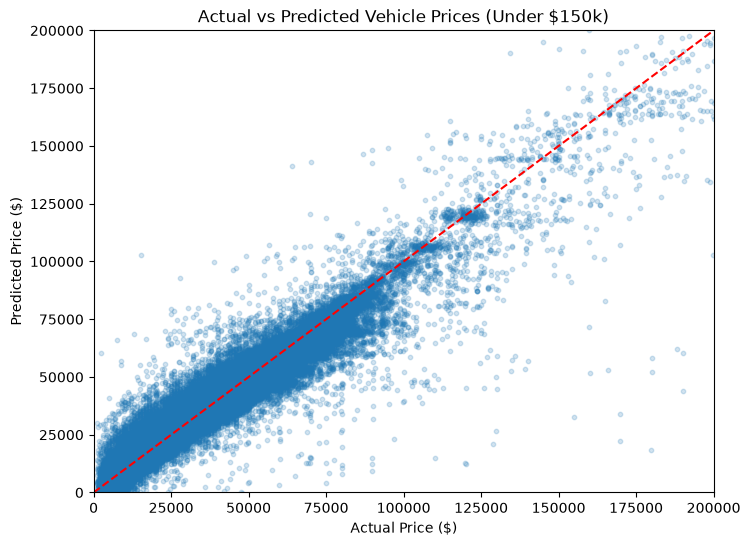

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val_v1, val_pred, alpha=0.2, s=10)

plt.plot(
    [0, 200000],
    [0, 200000],
    linestyle="--",
    color="red"
)

plt.xlim(0, 200000)
plt.ylim(0, 200000)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Vehicle Prices (Under $150k)")

plt.show()

## 5. Regularized Baseline — Ridge Regression

In [ ]:
ridge_model = Ridge(alpha=0.01)

ridge_model.fit(X_train_processed, y_train_V1)

ridge_val_pred = ridge_model.predict(X_val_processed)
ridge_train_pred = ridge_model.predict(X_train_processed)

ridge_mae = mean_absolute_error(y_val_v1, ridge_val_pred)

ridge_val_rmse = np.sqrt(
    mean_squared_error(y_val_v1, ridge_val_pred)
)

ridge_train_rmse = np.sqrt(
    mean_squared_error(y_train_V1, ridge_train_pred)
)

ridge_r2 = r2_score(y_val_v1, ridge_val_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge Val RMSE:", ridge_val_rmse)
print("Ridge Train RMSE:", ridge_train_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 2961.2482925831473
Ridge Val RMSE: 4664.9782144067185
Ridge Train RMSE: 4583.6685002749455
Ridge R²: 0.9296067689870335


## 6. Final Model — LightGBM

In [20]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    
    n_estimators=500,
    max_depth=20,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    force_row_wise=True,
    random_state=42,
    n_jobs=-1
)


lgbm.fit(
    X_train_processed,
    y_train_V1,
    eval_set=[(X_val_processed, y_val_v1)]
)

train_pred_lgbm = lgbm.predict(X_train_processed)
val_pred_lgbm = lgbm.predict(X_val_processed)

train_rmse_lgbm = np.sqrt(mean_squared_error(y_train_V1, train_pred_lgbm))
val_rmse_lgbm = np.sqrt(mean_squared_error(y_val_v1, val_pred_lgbm))
val_mae_lgbm = mean_absolute_error(y_val_v1, val_pred_lgbm)
val_r2_lgbm = r2_score(y_val_v1, val_pred_lgbm)

print("Train RMSE:", train_rmse_lgbm)
print("Val RMSE:", val_rmse_lgbm)
print("Val MAE:", val_mae_lgbm)
print("Val R²:", val_r2_lgbm)

c:\Users\casey\vehicle-valuation-platform\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Total Bins 21614
[LightGBM] [Info] Number of data points in the train set: 2128455, number of used features: 10521
[LightGBM] [Info] Start training from score 29504.898440
Train RMSE: 3623.840317641611
Val RMSE: 3660.0445624486106
Val MAE: 2380.113815185634
Val R²: 0.9566684318766773


## 7. Validation Error Analysis

In [21]:
abs_errors = np.abs(y_val_v1 - val_pred_lgbm)

print(abs_errors.mean())
print(np.median(abs_errors))
print(np.percentile(abs_errors, [50, 75, 90, 95, 99]))

2380.113815185634
1698.2170204134745
[ 1698.21702041  3151.99373351  5098.2354765   6653.53415554
 11192.55032245]


In [22]:
price_bands = pd.cut(
    y_val_v1,
    bins=[1000, 25000, 50000, 100000, 150000, 200000],
    labels=["1k-25k", "25k-50k", "50k-100k", "100k-150k", "150k-200k"],
    include_lowest=True
)

price_bands.value_counts().sort_index()

price
1k-25k       125780
25k-50k      111853
50k-100k      27050
100k-150k      1107
150k-200k       291
Name: count, dtype: int64

In [23]:
eval_df = pd.DataFrame({
    "actual": y_val_v1,
    "predicted": val_pred_lgbm,
    "price_band": price_bands
})

eval_df["abs_error"] = np.abs(
    eval_df["actual"] - eval_df["predicted"]
)

eval_df["squared_error"] = (
    eval_df["actual"] - eval_df["predicted"]
) ** 2

In [24]:
band_metrics = eval_df.groupby("price_band", observed=True).agg(
    count=("actual", "size"),
    MAE=("abs_error", "mean"),
    MSE=("squared_error", "mean")
)

band_metrics["RMSE"] = np.sqrt(band_metrics["MSE"])

band_metrics

,count,MAE,MSE,RMSE
price_band,,,,
1k-25k,125780,1663.223613,5.264204e+06,2294.385421
25k-50k,111853,2577.800173,1.163398e+07,3410.861800
50k-100k,27050,4428.218467,3.792916e+07,6158.665581
100k-150k,1107,9599.020565,2.816368e+08,16782.037856
150k-200k,291,18414.742167,9.045315e+08,30075.430902


In [25]:
test_mask = (y_test >= 1000) & (y_test <= 200000)

X_test_v1 = X_test.loc[test_mask]
y_test_v1 = y_test.loc[test_mask]

In [26]:
X_test_processed = preprocessor.transform(X_test_v1)

In [27]:
test_pred_lgbm = lgbm.predict(X_test_processed)

In [28]:
test_mae = mean_absolute_error(y_test_v1, test_pred_lgbm)
test_rmse = np.sqrt(mean_squared_error(y_test_v1, test_pred_lgbm))
test_r2 = r2_score(y_test_v1, test_pred_lgbm)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test MAE: 2378.998994226134
Test RMSE: 3685.2873812450757
Test R²: 0.9556645775807652


## 9. Freeze V1 Artifacts

In [29]:
import joblib

joblib.dump(preprocessor, "../models/v1/preprocessor.joblib")
joblib.dump(lgbm, "../models/v1/lightgbm.joblib")

['../models/v1/lightgbm.joblib']

## 10. V1 Report Figures

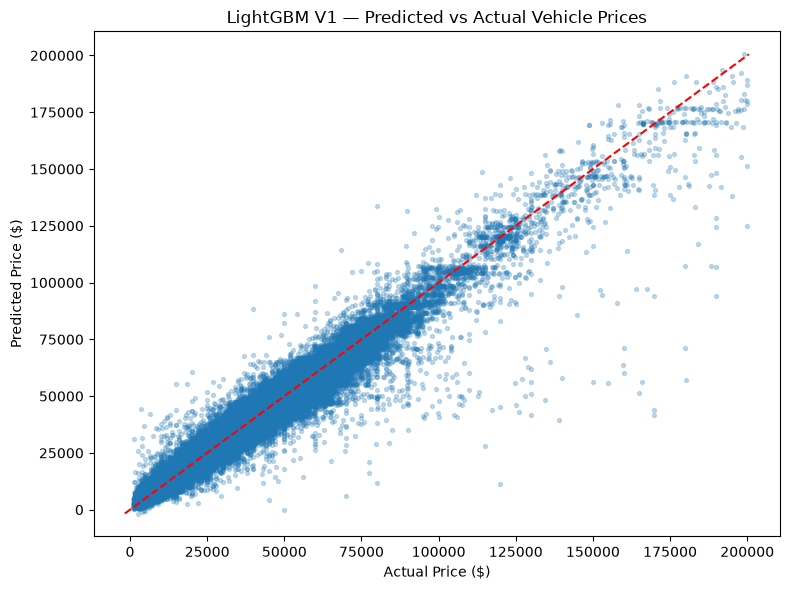

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val_v1,
    val_pred_lgbm,
    alpha=0.25,
    s=8

)

min_price = min(y_val_v1.min(), val_pred_lgbm.min())
max_price = max(y_val_v1.max(), val_pred_lgbm.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
    color = "red"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("LightGBM V1 — Predicted vs Actual Vehicle Prices")

plt.tight_layout()

plt.savefig(
    "../reports/figures/predicted_vs_actual_v1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

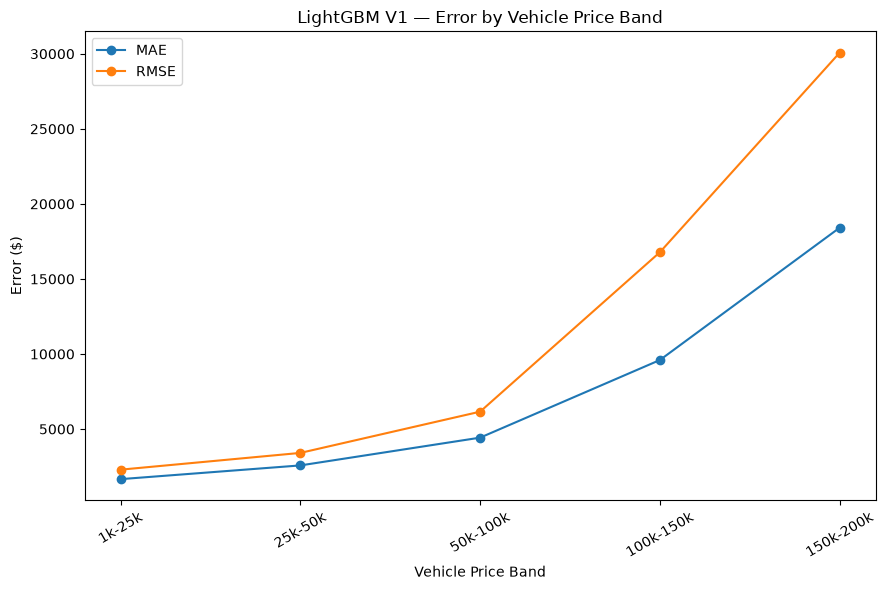

In [34]:
plt.figure(figsize=(9, 6))

x = range(len(band_metrics))

plt.plot(
    x,
    band_metrics["MAE"],
    marker="o",
    label="MAE"
)

plt.plot(
    x,
    band_metrics["RMSE"],
    marker="o",
    label="RMSE"
)

plt.xticks(
    x,
    band_metrics.index.astype(str),
    rotation=30
)

plt.xlabel("Vehicle Price Band")
plt.ylabel("Error ($)")
plt.title("LightGBM V1 — Error by Vehicle Price Band")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/figures/price_band_error_v1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

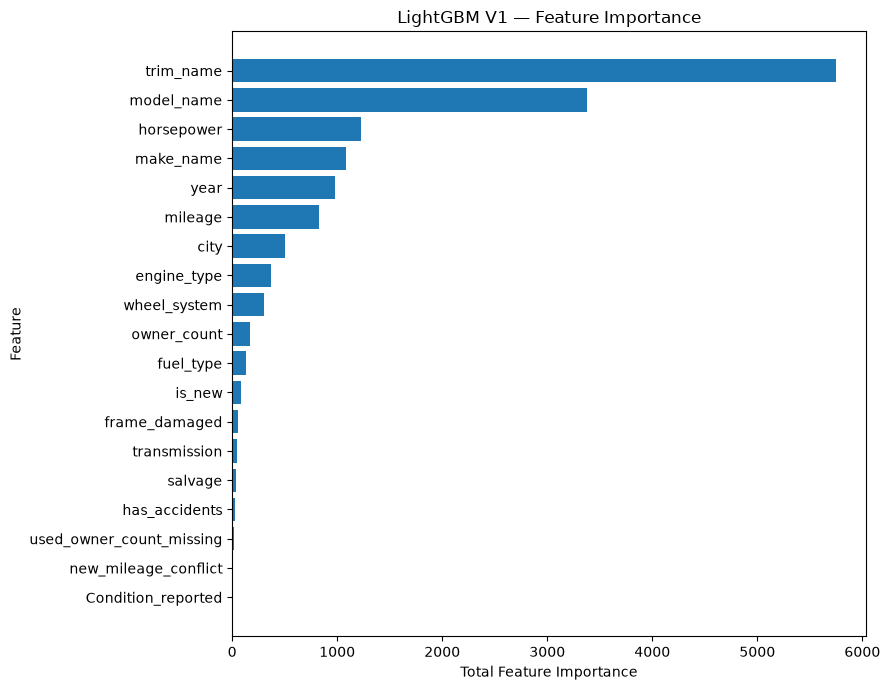

In [37]:


# Get transformed feature names + LightGBM importances
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm.feature_importances_
})

# Map one-hot encoded features back to their original feature
original_features = list(X_train_V1.columns)

def get_original_feature(transformed_name):
    name = transformed_name.split("__", 1)[-1]

    for feature in original_features:
        if name == feature or name.startswith(feature + "_"):
            return feature

    return name

importance_df["original_feature"] = importance_df["feature"].apply(
    get_original_feature
)

# Add importance across all encoded versions of each original feature
feature_importance = (
    importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=True)
)

# Plot
plt.figure(figsize=(9, 7))

plt.barh(
    feature_importance.index,
    feature_importance.values
)

plt.xlabel("Total Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM V1 — Feature Importance")

plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_importance_v1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
X_val_v1

NameError: name 'X_val_v1' is not defined